# RY25 Stage 1 — Data Understanding & Quality Analysis

This notebook is designed for the capstone **Statistical Core Refinement: Robustness and Efficiency of Minimal-Effects Testing**.

It analyses:
- `RY25_PreMay10.csv`
- `RY25_PostMay10.csv`
- official scale definitions from `Scoring instructions_Resilience Survey v6.docx`

### Goals
1. Understand dataset structure and schema.
2. Check duplicate and missing-data patterns.
3. Compare the two RY25 exports.
4. Inspect demographics and response distributions.
5. Reproduce selected official derived scores.
6. Export team-friendly summary tables.

> **Important:** This notebook does not automatically remove duplicates or impute missing values. Those decisions need methodological/client agreement.

## 0. Setup

In [1]:
from pathlib import Path
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

print("pandas:", pd.__version__)

pandas: 2.2.3


### Locate or extract the data
Put `Data.zip` in the same folder as this notebook, or edit `DATA_ZIP` / `DATA_DIR` below.

In [5]:
# Candidate locations make the notebook work both in ChatGPT and on your local machine.
# DATA_ZIP_CANDIDATES = [
#     Path("Data.zip"),
#     Path("/mnt/data/Data.zip"),
# ]

# DATA_DIR_CANDIDATES = [
#     Path("Data"),
#     Path("/mnt/data/Data"),
#     Path("/mnt/data/capstone_data_tmp/Data"),
# ]

# def find_existing(paths):
#     for p in paths:
#         if p.exists():
#             return p
#     return None

# DATA_DIR = find_existing(DATA_DIR_CANDIDATES)

# if DATA_DIR is None:
#     DATA_ZIP = find_existing(DATA_ZIP_CANDIDATES)
#     if DATA_ZIP is None:
#         raise FileNotFoundError(
#             "Could not find Data.zip or Data/. Put Data.zip beside the notebook, then rerun this cell."
#         )
#     extract_root = Path("capstone_data")
#     extract_root.mkdir(exist_ok=True)
#     with zipfile.ZipFile(DATA_ZIP, "r") as z:
#         z.extractall(extract_root)
#     DATA_DIR = extract_root / "Data"

# PRE_PATH = DATA_DIR / "RY25_PreMay10.csv"
# POST_PATH = DATA_DIR / "RY25_PostMay10.csv"


PRE_PATH = "RY25_PreMay10.csv"
POST_PATH = "RY25_PostMay10.csv"



# print("Using data directory:", DATA_DIR.resolve())
# print("Pre exists :", PRE_PATH.exists())
# print("Post exists:", POST_PATH.exists())

## 1. Load the two survey files

In [6]:
pre = pd.read_csv(PRE_PATH, low_memory=False)
post = pd.read_csv(POST_PATH, low_memory=False)

print(f"Pre : {pre.shape[0]:,} rows × {pre.shape[1]} columns")
print(f"Post: {post.shape[0]:,} rows × {post.shape[1]} columns")

Pre : 114,770 rows × 81 columns
Post: 71,063 rows × 85 columns


## 2. Basic structure
Use this section to answer: *What does the dataset look like? What types of variables are present?*

In [7]:
display(pre.head())
display(post.head())

,school,timestamp,postcode,accessCode,age,grade,gender,gender.1,culture,birthplace,nonenglish,language,cantril,ry2,ry3,ry4,ry5,ry6,ry7,ry8,ry9,ry10,ry11,ry13,ry14,ry15,ry35,sun3,ry36,ry16,ry17,ry18,ry20,ry21,ry22,k12,for1,ry25,ry26,ry27,ry28,ry29,ry30,ry31,ry37,ry38,ry39,ry40,ry40.1,ph1,ph2,ph3,ph4,phq3,phq4,phq5,phq7,cop1,cop2,cop3,cop4,chs1,chs2,chs3,chs4,chs5,chs6,IINS,ry32,aud1,aud2,aud3,gam1,gam2,ry42,ry43,sm1,sm2,sm3,sm4,comments
0,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:30:51 GMT+1000 (Australian ...,2800,998310,11,6,M,M,Australian,Australia,No,NaN,6,4,1,4,3,3,1.0,4,1.0,1,1,4,4,1,1,1,1,1,1,1,1.0,2,1,3,1,1.0,2,4,2,4,4,4,3,4,4,4.0,4.0,1,4,1,1,1.0,1.0,1,1.0,1,4,1,1,1,1,1,1,1,1,5,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,4,4,4,1,do nothing
1,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:33:04 GMT+1000 (Australian ...,2800,998310,12,6,M,M,Other,Australia,No,NaN,6,4,4,4,4,4,4.0,3,4.0,4,2,3,4,2,3,4,4,3,4,3,4.0,4,4,4,2,4.0,4,4,4,4,4,3,4,4,4,3.0,3.0,2,4,3,4,1.0,4.0,4,4.0,4,4,4,4,6,5,5,5,6,6,5,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,3,3,1,NaN,depression support
2,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:34:45 GMT+1000 (Australian ...,2800,998310,12,6,M,M,Australian,Australia,No,NaN,8,4,4,4,4,4,4.0,4,3.0,3,2,4,4,4,3,3,2,4,4,4,4.0,4,4,4,3,4.0,4,4,3,3,4,4,4,4,4,3.0,3.0,3,4,4,4,4.0,4.0,4,4.0,4,1,4,4,5,6,6,4,4,6,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,2,"3,4,6",stop vaping
3,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:38:32 GMT+1000 (Australian ...,2800,998310,10,5,M,M,Australian,Australia,No,NaN,6,4,4,4,4,4,4.0,3,4.0,3,3,3,3,3,3,3,4,4,4,4,3.0,4,4,4,4,4.0,4,4,4,4,4,4,4,4,2,4.0,4.0,3,3,4,3,3.0,4.0,3,3.0,2,2,4,2,3,3,3,3,3,3,3,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,1,NaN,less screen time
4,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:40:23 GMT+1000 (Australian ...,2800,998310,11,5,M,M,Aboriginal,Australia,No,NaN,8,4,4,4,4,3,4.0,4,4.0,3,4,4,4,4,4,3,3,2,4,4,3.0,4,2,4,2,4.0,2,4,3,4,3,3,4,4,4,4.0,4.0,4,4,4,3,4.0,4.0,4,4.0,4,4,3,3,5,6,6,4,3,4,3,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,2,"3,4,6",stop vaping


,school,timestamp,postcode,accessCode,age,grade,gender,gender.1,culture,birthplace,nonenglish,language,cantril,ry2,ry3,ry4,ry5,ry6,ry7,ry8,ry9,ry10,ry11,ry13,ry14,ry15,ry35,sun3,ry36,phy1,ry16,ry17,ry18,ry20,ry21,ry22,k12,for1,ry25,ry26,ry27,ry28,ry29,ry30,ry31,ry37,ry38,ry39,ry40,ry40.1,ph1,ph2,ph3,ph4,phq3,phq4,phq5,phq7,cop1,cop2,cop3,cop4,chs1,chs2,chs3,chs4,chs5,chs6,IINS,ry32,aud1,aud2,aud3,gam1,gam2,ry42,ry43,sm1,sm2,sm5,sm6,sm7,sm3,sm4,comments
0,e45333c93d71295f9ac870febaefe0d6,Fri Nov 21 2025 09:46:01 GMT+1100 (Australian ...,3212,414974,12,6,F,F,Australian,Australia,No,NaN,3,1,2,1,1,4,1.0,1,4.0,3,1,2,4,4,3,2,4,4.0,3,2,3,3.0,2,2,3,2,4.0,3,1,4,4,3,3,4,4,4,2.0,2.0,3,3,1,4,1.0,4.0,1,2.0,1,1,2,1,3,1,3,2,2,1,4,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,3,3,4,2,3,2,"2,3,10",Make them happy
1,e45333c93d71295f9ac870febaefe0d6,Fri Nov 21 2025 09:47:00 GMT+1100 (Australian ...,3212,414974,11,6,F,F,Other,India,1,Hindi,5,3,2,4,3,3,4.0,3,4.0,4,3,2,2,3,3,3,4,3.0,4,4,4,4.0,3,3,3,4,4.0,4,2,3,2,2,2,4,4,3,4.0,4.0,2,2,4,4,2.0,1.0,4,4.0,3,1,2,2,5,4,3,4,1,4,5,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,2,2,4,1,3,1,NaN,Help people be able to talk about their proble...
2,e45333c93d71295f9ac870febaefe0d6,Fri Nov 21 2025 09:47:51 GMT+1100 (Australian ...,3212,414974,12,6,F,F,Australian,Australia,No,NaN,8,4,4,3,4,4,4.0,4,3.0,3,3,4,3,4,4,4,4,3.0,2,4,4,4.0,4,4,4,3,4.0,4,4,3,4,3,4,4,4,3,3.0,3.0,4,4,4,3,3.0,4.0,4,4.0,4,3,3,4,5,6,6,5,5,5,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,4,3,3,2,"2,4,6",I just want them to be happy and safe !! (I wa...
3,e45333c93d71295f9ac870febaefe0d6,Fri Nov 21 2025 09:47:54 GMT+1100 (Australian ...,3212,414974,11,6,F,F,"Australian,Asian",Australia,No,NaN,6,3,4,3,3,4,3.0,2,4.0,1,1,3,3,3,2,1,1,2.0,2,2,1,1.0,1,1,4,2,2.0,1,1,2,3,2,2,4,4,4,1.0,1.0,3,2,2,2,1.0,3.0,1,1.0,4,1,1,1,3,3,2,1,1,1,2,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2,4,3,2,4,4,"2,3,4,5,10",get rid of bullying !
4,e45333c93d71295f9ac870febaefe0d6,Fri Nov 21 2025 09:48:12 GMT+1100 (Australian ...,3212,414974,11,6,M,M,Australian,Australia,No,NaN,5,4,4,4,4,4,3.0,4,4.0,2,2,4,3,3,3,3,4,3.0,2,4,3,3.0,3,3,4,2,1.0,3,3,2,3,3,3,4,4,4,4.0,4.0,3,4,4,3,2.0,4.0,3,4.0,4,2,4,2,3,3,3,3,3,4,3,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,4,2,3,2,"3,4",Give them all the same chance in life


In [8]:
structure = pd.DataFrame({
    "pre_dtype": pre.dtypes.astype(str),
    "post_dtype": post.dtypes.astype(str)
})
display(structure.head(100))

,pre_dtype,post_dtype
IINS,int64,int64
accessCode,int64,int64
age,int64,int64
aud1,float64,float64
aud2,float64,float64
aud3,float64,float64
birthplace,object,object
cantril,int64,int64
chs1,int64,int64
chs2,int64,int64


## 3. Compare schemas

In [9]:
pre_cols = set(pre.columns)
post_cols = set(post.columns)

only_pre = sorted(pre_cols - post_cols)
only_post = sorted(post_cols - pre_cols)
common = sorted(pre_cols & post_cols)

print("Common columns:", len(common))
print("Only in Pre:", only_pre)
print("Only in Post:", only_post)

Common columns: 81
Only in Pre: []
Only in Post: ['phy1', 'sm5', 'sm6', 'sm7']


### Column order / names

In [10]:
schema_table = pd.DataFrame({
    "pre_columns": pd.Series(pre.columns),
    "post_columns": pd.Series(post.columns)
})
display(schema_table)

,pre_columns,post_columns
0,school,school
1,timestamp,timestamp
2,postcode,postcode
3,accessCode,accessCode
4,age,age
5,grade,grade
6,gender,gender
7,gender.1,gender.1
8,culture,culture
9,birthplace,birthplace


## 4. Duplicate analysis

**Do not delete duplicates yet.** First determine whether they are true repeated submissions, duplicated exports, or expected records.

In [11]:
def duplicate_summary(df, name):
    dup_rows = df.duplicated(keep=False)
    exact_dup_after_first = df.duplicated().sum()
    unique_rows = len(df.drop_duplicates())
    return pd.Series({
        "dataset": name,
        "rows": len(df),
        "unique_complete_rows": unique_rows,
        "duplicate_rows_after_first": int(exact_dup_after_first),
        "rows_in_duplicate_groups": int(dup_rows.sum()),
        "duplicate_after_first_pct": exact_dup_after_first / len(df) * 100
    })

dup_summary = pd.DataFrame([
    duplicate_summary(pre, "PreMay10"),
    duplicate_summary(post, "PostMay10")
])
display(dup_summary)

,dataset,rows,unique_complete_rows,duplicate_rows_after_first,rows_in_duplicate_groups,duplicate_after_first_pct
0,PreMay10,114770,66000,48770,97540,42.493683
1,PostMay10,71063,71027,36,72,0.050659


### Inspect duplicate examples

In [12]:
pre_duplicates = pre[pre.duplicated(keep=False)].copy()
post_duplicates = post[post.duplicated(keep=False)].copy()

print("Pre rows belonging to duplicate groups:", len(pre_duplicates))
print("Post rows belonging to duplicate groups:", len(post_duplicates))

# Show a small sample.
display(pre_duplicates.head(20))

Pre rows belonging to duplicate groups: 97540
Post rows belonging to duplicate groups: 72


,school,timestamp,postcode,accessCode,age,grade,gender,gender.1,culture,birthplace,nonenglish,language,cantril,ry2,ry3,ry4,ry5,ry6,ry7,ry8,ry9,ry10,ry11,ry13,ry14,ry15,ry35,sun3,ry36,ry16,ry17,ry18,ry20,ry21,ry22,k12,for1,ry25,ry26,ry27,ry28,ry29,ry30,ry31,ry37,ry38,ry39,ry40,ry40.1,ph1,ph2,ph3,ph4,phq3,phq4,phq5,phq7,cop1,cop2,cop3,cop4,chs1,chs2,chs3,chs4,chs5,chs6,IINS,ry32,aud1,aud2,aud3,gam1,gam2,ry42,ry43,sm1,sm2,sm3,sm4,comments
0,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:30:51 GMT+1000 (Australian ...,2800,998310,11,6,M,M,Australian,Australia,No,NaN,6,4,1,4,3,3,1.0,4,1.0,1,1,4,4,1,1,1,1,1,1,1,1.0,2,1,3,1,1.0,2,4,2,4,4,4,3,4,4,4.0,4.0,1,4,1,1,1.0,1.0,1,1.0,1,4,1,1,1,1,1,1,1,1,5,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,4,4,4,1,do nothing
1,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:33:04 GMT+1000 (Australian ...,2800,998310,12,6,M,M,Other,Australia,No,NaN,6,4,4,4,4,4,4.0,3,4.0,4,2,3,4,2,3,4,4,3,4,3,4.0,4,4,4,2,4.0,4,4,4,4,4,3,4,4,4,3.0,3.0,2,4,3,4,1.0,4.0,4,4.0,4,4,4,4,6,5,5,5,6,6,5,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,3,3,1,NaN,depression support
2,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:34:45 GMT+1000 (Australian ...,2800,998310,12,6,M,M,Australian,Australia,No,NaN,8,4,4,4,4,4,4.0,4,3.0,3,2,4,4,4,3,3,2,4,4,4,4.0,4,4,4,3,4.0,4,4,3,3,4,4,4,4,4,3.0,3.0,3,4,4,4,4.0,4.0,4,4.0,4,1,4,4,5,6,6,4,4,6,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,2,"3,4,6",stop vaping
3,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:38:32 GMT+1000 (Australian ...,2800,998310,10,5,M,M,Australian,Australia,No,NaN,6,4,4,4,4,4,4.0,3,4.0,3,3,3,3,3,3,3,4,4,4,4,3.0,4,4,4,4,4.0,4,4,4,4,4,4,4,4,2,4.0,4.0,3,3,4,3,3.0,4.0,3,3.0,2,2,4,2,3,3,3,3,3,3,3,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,1,NaN,less screen time
4,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:40:23 GMT+1000 (Australian ...,2800,998310,11,5,M,M,Aboriginal,Australia,No,NaN,8,4,4,4,4,3,4.0,4,4.0,3,4,4,4,4,4,3,3,2,4,4,3.0,4,2,4,2,4.0,2,4,3,4,3,3,4,4,4,4.0,4.0,4,4,4,3,4.0,4.0,4,4.0,4,4,3,3,5,6,6,4,3,4,3,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,2,"3,4,6",stop vaping
5,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:40:44 GMT+1000 (Australian ...,2800,998310,10,5,M,M,Australian,Australia,No,NaN,6,4,4,4,4,3,3.0,4,3.0,4,2,4,3,3,3,3,2,4,4,4,4.0,4,4,3,2,2.0,3,4,4,4,4,4,4,3,4,3.0,3.0,4,4,4,4,3.0,4.0,3,4.0,2,3,4,3,3,4,4,4,2,1,3,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,2,3,2,"2,3,4",stop smoking/vaping
6,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:41:16 GMT+1000 (Australian ...,2800,998310,12,6,M,M,Australian,Australia,No,NaN,8,2,4,4,1,4,4.0,2,4.0,3,2,4,4,4,3,4,4,2,4,4,3.0,3,4,4,2,4.0,3,3,3,4,3,2,4,4,4,4.0,4.0,4,4,4,4,4.0,4.0,4,4.0,3,3,4,3,5,5,5,5,3,3,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,2,"2,4,6,10",stop self harm
7,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:43:26 GMT+1000 (Australian ...,2800,998310,11,5,M,M,Aboriginal,Australia,1,Arabic,5,4,3,3,4,4,3.0,3,4.0,3,3,4,3,4,3,2,3,2,3,3,3.0,3,3,3,2,4.0,2,3,3,4,3,3,4,4,4,3.0,3.0,4,4,4,4,3.0,4.0,4,4.0,2,2,3,3,5,3,4,5,4,4,5,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2,4,4,"2,3,4,9",no smokings 4 dem :D
8,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:43:50 GMT+1000 (Australian ...,2800,998310,11,6,M,M,Torres Strait Islander,Australia,1,English,8,4,4,1,3,4,3.0,3,3.0,3,3,3,3,4,3,3,3,2,4,4,4.0,4,4,3,3,2.0,3,3,3,3,4,3,4,4,4,4.0,4.0,1,4,4,4,4.0,4.0,4,3.0,4,2,3,3,2,1,2,2,2,2,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,2,2,1,NaN,helping them
9,0cb5e7b8835ffd7aa0cf0f908d8b74ae,Mon May 19 2025 09:46:26 GMT+1000 (Australian ...,2800,998310,10,5,M,M,Māori,Australia,No,NaN,6,4,4,4,4,4,3.0,4,4.0,3,2,3,3,2,4,2,4,2,3,4,3.0,2,4,3,4,4.0,4,3,3,4,4,4,3,4,4,3.0,3.0,3,2,3,3,1.0,2.0,3,3.0,3,3,2,2,5,3,5,2,4,4,4,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,2,1,1,NaN,be encoureged every where they go


### Optional: inspect duplicate counts for likely identifiers
This does not assume any one field uniquely identifies a respondent.

In [13]:
candidate_cols = [c for c in ["school", "timestamp", "accessCode", "postcode", "age", "grade", "gender"] if c in pre.columns]
print("Available candidate metadata columns:", candidate_cols)

if candidate_cols:
    display(
        pre_duplicates[candidate_cols]
        .value_counts(dropna=False)
        .head(20)
        .rename("count")
        .reset_index()
    )

Available candidate metadata columns: ['school', 'timestamp', 'accessCode', 'postcode', 'age', 'grade', 'gender']


,school,timestamp,accessCode,postcode,age,grade,gender,count
0,84a42918156401ff26c3386d42ae2af3,Thu Feb 27 2025 15:04:38 GMT+1100 (Australian ...,559944,3810,10,5,M,12
1,84a42918156401ff26c3386d42ae2af3,Fri Feb 21 2025 10:02:04 GMT+1100 (Australian ...,559944,3810,8,3,M,10
2,84a42918156401ff26c3386d42ae2af3,Thu Feb 20 2025 13:26:12 GMT+1100 (Australian ...,559944,3810,8,3,F,10
3,9c3f7e4912ddc77f0012db48a1ccc580,Thu Mar 13 2025 13:30:55 GMT+1000 (Australian ...,817086,4567,8,3,F,8
4,735ff7d83631b5b3809616dc9b00e4b0,Thu Apr 03 2025 09:28:19 GMT+0800 (Australian ...,318704,6180,9,4,M,8
5,09288d5fe848d9fee34e3ce74b7da8e1,Wed May 14 2025 13:43:21 GMT+1000 (Australian ...,631756,4655,8,3,M,8
6,cb696cdcad625ecf1d96a803e9a37e99,Fri Mar 21 2025 13:19:09 GMT+1000 (Australian ...,890445,4012,11,6,F,8
7,f7a2542b55bd29aa76cdf00c77805491,Fri May 23 2025 12:24:16 GMT+1000 (Australian ...,857595,3101,12,6,F,8
8,09288d5fe848d9fee34e3ce74b7da8e1,Wed May 14 2025 13:43:22 GMT+1000 (Australian ...,631756,4655,8,3,F,8
9,a83a875578b148953edbd5137d3bee84,Fri Mar 28 2025 09:14:59 GMT+1000 (Australian ...,683546,4551,10,5,M,8


## 5. Missing-data analysis
High missingness may be caused by survey branching or eligibility rules, so treat it as a pattern to understand—not automatically as bad data.

In [14]:
def missing_summary(df):
    return (
        pd.DataFrame({
            "missing_n": df.isna().sum(),
            "missing_pct": df.isna().mean() * 100,
            "non_missing_n": df.notna().sum()
        })
        .sort_values("missing_pct", ascending=False)
    )

missing_pre = missing_summary(pre)
missing_post = missing_summary(post)

print("PRE — highest missingness")
display(missing_pre.head(30))

print("POST — highest missingness")
display(missing_post.head(30))

PRE — highest missingness


,missing_n,missing_pct,non_missing_n
language,76292,66.473817,38478
aud3,61488,53.574976,53282
aud1,61488,53.574976,53282
ry42,61488,53.574976,53282
ry43,61488,53.574976,53282
ry32,61488,53.574976,53282
aud2,61488,53.574976,53282
gam1,61488,53.574976,53282
phq3,29835,25.995469,84935
ry7,29835,25.995469,84935


POST — highest missingness


,missing_n,missing_pct,non_missing_n
phy1,47812,67.281145,23251
language,43248,60.858675,27815
aud1,32955,46.374344,38108
ry32,32955,46.374344,38108
aud2,32955,46.374344,38108
aud3,32955,46.374344,38108
ry43,32955,46.374344,38108
ry42,32955,46.374344,38108
gam1,32955,46.374344,38108
ry25,15570,21.910136,55493


### Missingness comparison for common variables

In [15]:
missing_compare = pd.DataFrame({
    "pre_missing_pct": pre[common].isna().mean() * 100,
    "post_missing_pct": post[common].isna().mean() * 100,
})
missing_compare["difference_pp"] = missing_compare["post_missing_pct"] - missing_compare["pre_missing_pct"]
missing_compare = missing_compare.sort_values("difference_pp", key=lambda s: s.abs(), ascending=False)
display(missing_compare.head(40))

,pre_missing_pct,post_missing_pct,difference_pp
aud2,53.574976,46.374344,-7.200632
aud3,53.574976,46.374344,-7.200632
aud1,53.574976,46.374344,-7.200632
ry42,53.574976,46.374344,-7.200632
gam1,53.574976,46.374344,-7.200632
ry32,53.574976,46.374344,-7.200632
ry43,53.574976,46.374344,-7.200632
language,66.473817,60.858675,-5.615143
sm4,22.979873,18.304884,-4.674988
phq3,25.995469,21.910136,-4.085333


### Plot the top missing variables

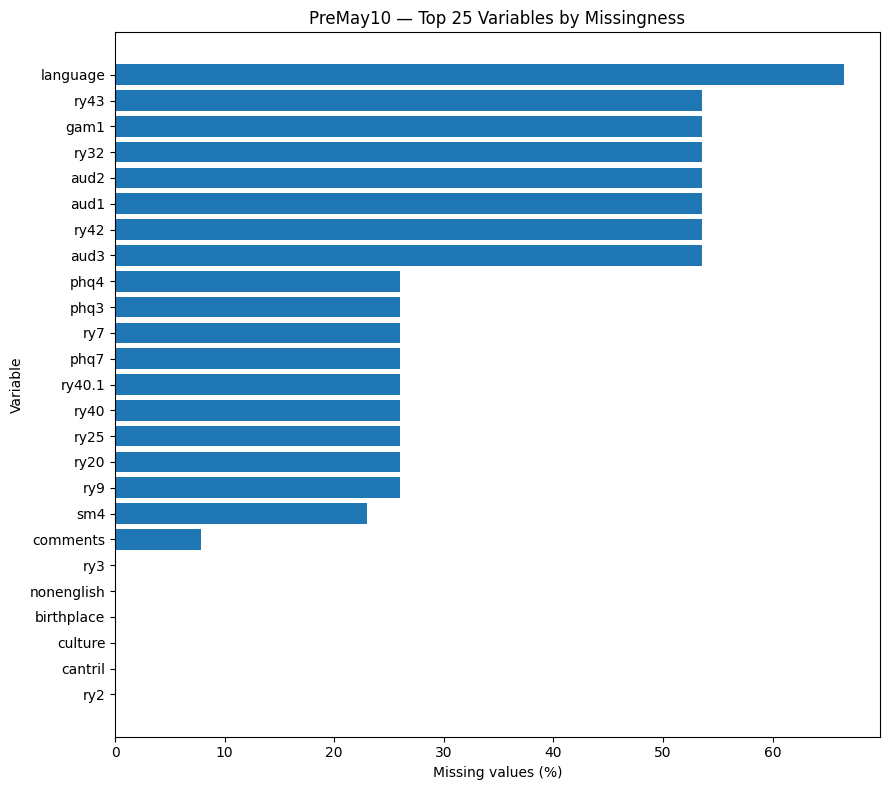

In [16]:
top_n = 25
plot_data = missing_pre.head(top_n).sort_values("missing_pct")

plt.figure(figsize=(9, 8))
plt.barh(plot_data.index, plot_data["missing_pct"])
plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title(f"PreMay10 — Top {top_n} Variables by Missingness")
plt.tight_layout()
plt.show()

## 6. Timestamp coverage
The filenames alone should not be assumed to define strict before/after periods. Check the actual timestamp ranges.

In [18]:
def timestamp_check(df, name):
    if "timestamp" not in df.columns:
        print(name, "has no timestamp column")
        return None
    ts = pd.to_datetime(df["timestamp"], errors="coerce", dayfirst=True)
    print(name)
    print("  parsed:", f"{ts.notna().sum():,}/{len(ts):,}")
    # Filter out NaT values before calling min() and max()
    valid_ts = ts.dropna()
    if not valid_ts.empty:
        print("  min:", valid_ts.min())
        print("  max:", valid_ts.max())
    else:
        print("  min: No valid timestamps found")
        print("  max: No valid timestamps found")
    return ts

pre_ts = timestamp_check(pre, "PreMay10")
post_ts = timestamp_check(post, "PostMay10")

PreMay10
  parsed: 418/114,770
  min: 2025-02-04 12:16:50-10:00
  max: 2025-08-13 13:51:49-10:00
PostMay10
  parsed: 193/71,063
  min: 2025-05-12 10:30:16-08:00
  max: 2025-12-03 11:47:26-11:00


### Responses over time

In [21]:
if pre_ts is not None and post_ts is not None:
    pre_month = pre_ts.dt.to_period("M").value_counts().sort_index()
    post_month = post_ts.dt.to_period("M").value_counts().sort_index()
    monthly = pd.concat([pre_month.rename("Pre"), post_month.rename("Post")], axis=1).fillna(0)
    display(monthly)

    monthly.plot(kind="bar", figsize=(10,5))
    plt.ylabel("Responses")
    plt.xlabel("Month")
    plt.title("Survey Responses by Month")
    plt.tight_layout()
    plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

## 7. Demographic understanding

In [22]:
demographic_cols = [c for c in [
    "school", "age", "grade", "gender", "culture", "birthplace", "language", "postcode"
] if c in pre.columns or c in post.columns]

print("Demographic / metadata fields found:", demographic_cols)

Demographic / metadata fields found: ['school', 'age', 'grade', 'gender', 'culture', 'birthplace', 'language', 'postcode']


In [23]:
def show_value_counts(df, col, top=20):
    if col not in df.columns:
        return
    print(f"\n### {col}")
    out = df[col].value_counts(dropna=False).head(top).rename("count").to_frame()
    out["pct"] = out["count"] / len(df) * 100
    display(out)

for col in ["grade", "age", "gender"]:
    show_value_counts(pre, col)


### grade


,count,pct
grade,,
6,16103,14.030670
5,15550,13.548837
4,15110,13.165461
3,14725,12.830008
7,14724,12.829137
8,11955,10.416485
9,10038,8.746188
10,7574,6.599286
11,5275,4.596149



### age


,count,pct
age,,
11,15927,13.877320
10,15813,13.777991
9,14737,12.840464
12,14633,12.749848
13,12751,11.110046
8,12125,10.564607
14,10110,8.808922
15,7626,6.644594
16,5421,4.723360



### gender


,count,pct
gender,,
F,57582,50.171648
M,53651,46.746537
P,2731,2.379542
O,806,0.702274


### Number of schools

In [24]:
for name, df in [("Pre", pre), ("Post", post)]:
    if "school" in df.columns:
        print(name, "unique non-missing schools:", df["school"].nunique(dropna=True))

Pre unique non-missing schools: 358
Post unique non-missing schools: 326


## 8. Numeric response ranges
This helps identify impossible values or unexpected coding before any scale calculations.

In [25]:
numeric_pre = pre.select_dtypes(include=np.number)
range_table = pd.DataFrame({
    "count": numeric_pre.count(),
    "missing": numeric_pre.isna().sum(),
    "min": numeric_pre.min(),
    "max": numeric_pre.max(),
    "mean": numeric_pre.mean(),
    "std": numeric_pre.std()
})
display(range_table)

,count,missing,min,max,mean,std
accessCode,114770,0,9391.0,998310.0,485504.879080,287450.753968
age,114770,0,7.0,20.0,11.595469,2.563521
grade,114770,0,3.0,12.0,6.503355,2.503223
cantril,114770,0,1.0,8.0,5.940211,1.509096
ry2,114770,0,1.0,4.0,3.540812,0.725023
ry3,114770,0,1.0,4.0,3.117635,0.929865
ry4,114770,0,1.0,4.0,3.139906,0.924771
ry5,114770,0,1.0,4.0,3.577294,0.722263
ry6,114770,0,1.0,4.0,3.653516,0.701907
ry7,84935,29835,1.0,4.0,3.375358,0.787170


## 9. Official derived scales

The following examples follow the supplied scoring instructions:

- **Children’s Hope Scale**: sum `chs1`–`chs6`; missing if any item missing.
- **Anxiety Symptoms**: reverse `ph1`, `ph2` using `5 - x`, then sum; missing if either missing.
- **Depression Symptoms**: reverse `ph3`, `ph4`, then sum; missing if either missing.
- **Avoidance Coping**: reverse `cop1`–`cop4`, then sum; missing if any missing.
- **School Engagement**: mean of `ry16`, `ry17`, `ry18`, `ry20`, `ry28`; missing if any missing.
- **Friendship**: mean of `ry6`, `ry9`, `ry10`, `ry29`, `k12`; missing if any missing.
- **Family Support**: mean of `ry2`, `ry5`, `ry7`, `ry8`, `ry13`, `ry27`; missing if any missing.
- **Experience of Being Bullied**: mean of `ry37`, `ry38`, `ry39`; higher = less frequent bullying.

We calculate these on copies so the raw data stays unchanged.

In [26]:
def strict_sum(df, cols):
    """Sum only when ALL required items are present."""
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")
    return df[cols].sum(axis=1, min_count=len(cols))

def strict_mean(df, cols):
    """Mean only when ALL required items are present."""
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")
    return df[cols].mean(axis=1).where(df[cols].notna().all(axis=1))

def reverse_1_to_4(series):
    """Official reverse coding: 1↔4, 2↔3."""
    return 5 - series

def add_official_scales(df):
    x = df.copy()

    # Hope
    chs = ["chs1", "chs2", "chs3", "chs4", "chs5", "chs6"]
    if set(chs).issubset(x.columns):
        x["hope_score"] = strict_sum(x, chs)

    # Anxiety
    anx = ["ph1", "ph2"]
    if set(anx).issubset(x.columns):
        x["anxiety_score"] = strict_sum(pd.DataFrame({c: reverse_1_to_4(x[c]) for c in anx}), anx)

    # Depression
    dep = ["ph3", "ph4"]
    if set(dep).issubset(x.columns):
        x["depression_score"] = strict_sum(pd.DataFrame({c: reverse_1_to_4(x[c]) for c in dep}), dep)

    # Avoidance coping
    cop = ["cop1", "cop2", "cop3", "cop4"]
    if set(cop).issubset(x.columns):
        rev = pd.DataFrame({c: reverse_1_to_4(x[c]) for c in cop})
        x["avoidance_coping_score"] = strict_sum(rev, cop)

    # Mean-based scales
    scale_means = {
        "school_engagement_score": ["ry16", "ry17", "ry18", "ry20", "ry28"],
        "friendship_score": ["ry6", "ry9", "ry10", "ry29", "k12"],
        "family_support_score": ["ry2", "ry5", "ry7", "ry8", "ry13", "ry27"],
        "bullying_score": ["ry37", "ry38", "ry39"],
    }
    for new_col, cols in scale_means.items():
        if set(cols).issubset(x.columns):
            x[new_col] = strict_mean(x, cols)

    # Raw-score single item
    if "cantril" in x.columns:
        x["life_satisfaction_score"] = x["cantril"]

    return x

pre_scored = add_official_scales(pre)
post_scored = add_official_scales(post)

score_cols = [c for c in pre_scored.columns if c.endswith("_score")]
print("Derived scores created:", score_cols)

Derived scores created: ['hope_score', 'anxiety_score', 'depression_score', 'avoidance_coping_score', 'school_engagement_score', 'friendship_score', 'family_support_score', 'bullying_score', 'life_satisfaction_score']


## 10. Validate expected score ranges
If values fall outside these ranges, investigate raw coding before continuing.

In [27]:
expected_ranges = {
    "hope_score": (6, 36),
    "anxiety_score": (2, 8),
    "depression_score": (2, 8),
    "avoidance_coping_score": (4, 16),
    "school_engagement_score": (1, 4),
    "friendship_score": (1, 4),
    "family_support_score": (1, 4),
    "bullying_score": (1, 4),
    "life_satisfaction_score": (1, 8),
}

checks = []
for col, (lo, hi) in expected_ranges.items():
    if col not in pre_scored.columns:
        continue
    s = pre_scored[col]
    checks.append({
        "score": col,
        "expected_min": lo,
        "expected_max": hi,
        "observed_min": s.min(),
        "observed_max": s.max(),
        "non_missing_n": s.notna().sum(),
        "outside_expected_n": ((s < lo) | (s > hi)).sum(),
        "missing_pct": s.isna().mean() * 100,
    })

score_validation = pd.DataFrame(checks)
display(score_validation)

,score,expected_min,expected_max,observed_min,observed_max,non_missing_n,outside_expected_n,missing_pct
0,hope_score,6,36,6.0,36.0,114770,0,0.000000
1,anxiety_score,2,8,2.0,8.0,114770,0,0.000000
2,depression_score,2,8,2.0,8.0,114770,0,0.000000
3,avoidance_coping_score,4,16,4.0,16.0,114770,0,0.000000
4,school_engagement_score,1,4,1.0,4.0,84935,0,25.995469
5,friendship_score,1,4,1.0,4.0,84935,0,25.995469
6,family_support_score,1,4,1.0,4.0,84935,0,25.995469
7,bullying_score,1,4,1.0,4.0,114770,0,0.000000
8,life_satisfaction_score,1,8,1.0,8.0,114770,0,0.000000


## 11. Score categories
These categories are from the supplied scoring instructions.

In [28]:
def add_score_categories(df):
    x = df.copy()

    if "hope_score" in x:
        x["hope_category"] = pd.cut(
            x["hope_score"], bins=[-np.inf, 18, 27, np.inf],
            labels=["Low", "Mid", "High"]
        )

    for score, category in [("anxiety_score", "anxiety_category"),
                            ("depression_score", "depression_category")]:
        if score in x:
            x[category] = pd.cut(
                x[score], bins=[-np.inf, 3, 5, np.inf],
                labels=["Low", "Mid", "High"]
            )

    if "avoidance_coping_score" in x:
        x["avoidance_coping_category"] = pd.cut(
            x["avoidance_coping_score"], bins=[-np.inf, 8, 10, np.inf],
            labels=["Low", "Mid", "High"]
        )

    if "life_satisfaction_score" in x:
        x["life_satisfaction_category"] = pd.cut(
            x["life_satisfaction_score"], bins=[-np.inf, 4, 6, np.inf],
            labels=["Struggling", "Doing OK", "Thriving"]
        )

    return x

pre_scored = add_score_categories(pre_scored)
post_scored = add_score_categories(post_scored)

### Category distributions

In [ ]:
category_cols = [c for c in pre_scored.columns if c.endswith("_category")]
for col in category_cols:
    print("\n", col)
    out = pre_scored[col].value_counts(dropna=False).rename("count").to_frame()
    out["pct"] = out["count"] / len(pre_scored) * 100
    display(out)

## 12. Descriptive statistics for derived scales

In [ ]:
score_summary_pre = pre_scored[score_cols].describe().T
score_summary_pre["missing_n"] = pre_scored[score_cols].isna().sum()
score_summary_pre["missing_pct"] = pre_scored[score_cols].isna().mean() * 100
display(score_summary_pre)

## 13. Plot score distributions

In [ ]:
for col in score_cols:
    s = pre_scored[col].dropna()
    if s.empty:
        continue
    plt.figure(figsize=(7,4))
    plt.hist(s, bins=min(30, max(5, s.nunique())))
    plt.xlabel(col)
    plt.ylabel("Number of responses")
    plt.title(f"PreMay10 — Distribution of {col}")
    plt.tight_layout()
    plt.show()

## 14. Group summaries
Use these descriptively in Stage 1. Do not interpret group differences as causal or statistically meaningful yet.

In [ ]:
def group_score_summary(df, group_col, score_col):
    if group_col not in df.columns or score_col not in df.columns:
        return pd.DataFrame()
    return (
        df.groupby(group_col, dropna=False)[score_col]
          .agg(n="count", mean="mean", median="median", std="std")
          .sort_values("n", ascending=False)
    )

for group in ["grade", "gender"]:
    if "hope_score" in pre_scored.columns:
        print(f"\nHope by {group}")
        display(group_score_summary(pre_scored, group, "hope_score"))

## 15. Compare Pre and Post derived-score summaries
This is descriptive only. The two files should not be treated as experimental pre/post groups until their provenance is confirmed.

In [ ]:
def compact_score_summary(df, dataset_name):
    cols = [c for c in score_cols if c in df.columns]
    rows=[]
    for c in cols:
        s=df[c]
        rows.append({
            "dataset": dataset_name,
            "score": c,
            "n": s.notna().sum(),
            "missing_pct": s.isna().mean()*100,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
        })
    return pd.DataFrame(rows)

pre_score_summary = compact_score_summary(pre_scored, "PreMay10")
post_score_summary = compact_score_summary(post_scored, "PostMay10")
score_compare = pd.concat([pre_score_summary, post_score_summary], ignore_index=True)
display(score_compare)

## 16. Raw-item frequency tables
This is useful for checking whether categorical survey items use the expected response coding.

In [ ]:
example_items = [
    "chs1", "chs2", "ph1", "ph2", "cop1",
    "ry16", "ry6", "ry37", "cantril"
]

for col in example_items:
    if col not in pre.columns:
        continue
    print(f"\n### {col}")
    counts = pre[col].value_counts(dropna=False).sort_index().rename("count").to_frame()
    counts["pct"] = counts["count"] / len(pre) * 100
    display(counts)

## 17. Team-facing data quality flags
This creates a compact table of issues that should be discussed rather than automatically fixed.

In [ ]:
quality_flags = []

for name, df in [("PreMay10", pre), ("PostMay10", post)]:
    quality_flags.append({
        "dataset": name,
        "issue": "Exact duplicate rows",
        "count": int(df.duplicated().sum()),
        "pct": df.duplicated().mean()*100,
        "recommended_action": "Investigate provenance before removing"
    })

    high_missing = (df.isna().mean() >= 0.50).sum()
    quality_flags.append({
        "dataset": name,
        "issue": "Variables with >=50% missingness",
        "count": int(high_missing),
        "pct": np.nan,
        "recommended_action": "Check survey branching/eligibility rules"
    })

quality_flags = pd.DataFrame(quality_flags)
display(quality_flags)

## 18. Export summaries for the team
This writes small CSV outputs only; it does **not** rewrite the raw survey files.

In [ ]:
OUTPUT_DIR = Path("outputs/stage1_data_understanding")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dup_summary.to_csv(OUTPUT_DIR / "duplicate_summary.csv", index=False)
missing_pre.to_csv(OUTPUT_DIR / "missingness_pre.csv")
missing_post.to_csv(OUTPUT_DIR / "missingness_post.csv")
missing_compare.to_csv(OUTPUT_DIR / "missingness_pre_vs_post.csv")
score_validation.to_csv(OUTPUT_DIR / "score_validation_pre.csv", index=False)
score_compare.to_csv(OUTPUT_DIR / "derived_score_summary_pre_vs_post.csv", index=False)
quality_flags.to_csv(OUTPUT_DIR / "data_quality_flags.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(" -", p.name)

## 19. Questions for the team/client after running this notebook

Record answers to these before cleaning or statistical modelling:

1. Why does `RY25_PreMay10.csv` contain many exact duplicate rows?
2. What precisely do **PreMay10** and **PostMay10** mean operationally?
3. Are overlapping timestamp periods expected?
4. Which variables are conditionally shown by age/grade or survey branching?
5. Which columns are input variables used by the existing GemFinder pipeline?
6. Should duplicate records be retained for baseline reproduction even if they later require cleaning?
7. Which official derived scales are used directly in the current minimal-effects analysis?
8. Are there known exclusions, invalid-response rules, or consent filters not encoded in the CSV?

### Recommended next notebook
`02_baseline_feature_mapping.ipynb`: map raw RY25 columns → scoring/transformation → B-matrix/GemFinder inputs → existing baseline outputs.